# EDA - Visualization

## 1. Import thư viện

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from vitable.data import find_root, load_manifest, parse_markdown, read_label

DATA = find_root() / "data"
SPLITS = ["training_set", "public_test", "private_test"]
LEVELS = ["M1", "M2", "M3", "M4"]
LEVEL_COLORS = dict(zip(LEVELS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))  # mỗi mức một màu cố định

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "xtick.color": "#898781", "ytick.color": "#898781", "legend.frameon": False,
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
})

## 2. Quy mô ba tập

Mỗi dòng `manifest.jsonl` là một tài liệu. Test chỉ gồm M1–M2 nên thêm dòng `training_set (M1+M2)` để so sánh.

In [1]:
def read_split(split: str) -> pd.DataFrame:
    '''Manifest -> DataFrame, mỗi hàng một tài liệu (trải phẳng `attributes`).'''
    frame = pd.json_normalize(load_manifest(DATA / split))
    frame.columns = frame.columns.str.removeprefix("attributes.")
    return frame.loc[:, ~frame.columns.duplicated()]      # page_count có ở cả gốc lẫn attributes


frames = {split: read_split(split) for split in SPLITS}
train = frames["training_set"]
groups = {"training_set": train, "training_set (M1+M2)": train[train.difficulty.isin(["M1", "M2"])],
          "public_test": frames["public_test"], "private_test": frames["private_test"]}

paths = [DATA / split / path for split, frame in frames.items() for pages in frame.image_paths for path in pages]
paths += [DATA / "training_set" / path for path in train.label_path]
print(f"File thiếu: {sum(not path.is_file() for path in paths)} / {len(paths)}")

pd.DataFrame([{"Tập": name, "Tài liệu": len(group), "Ảnh trang": group.page_count.sum(),
               "% tài liệu 2 trang": round(100 * (group.page_count == 2).mean(), 1)}
              for name, group in groups.items()]).set_index("Tập")

File thiếu: 0 / 2613


,Tài liệu,Ảnh trang,% tài liệu 2 trang
Tập,,,
training_set,1100,1375,25.0
training_set (M1+M2),655,691,5.5
public_test,50,52,4.0
private_test,80,86,7.5


**Nhận xét**
- Train 1.100 tài liệu, test rất nhỏ (public 50, private 80) → mỗi tài liệu private ≈ 1,25 điểm. Không thiếu file nào.
- Cả tập train có 25% tài liệu 2 trang, nhưng phần M1+M2 chỉ 5,5% sát public (4%) và private (7,5%). → Đánh giá trên tập kiểm định nên nhìn **điểm M1+M2**.

## 3. Độ khó M1-M4 (training_set)

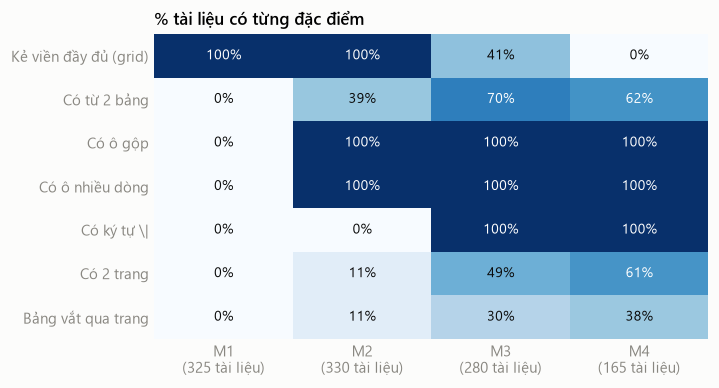

In [2]:
profile = pd.DataFrame({
    "Kẻ viền đầy đủ (grid)": train.border_mode.eq("grid"),
    "Có từ 2 bảng": train.table_count.ge(2),
    "Có ô gộp": train.has_merge,
    "Có ô nhiều dòng": train.has_multiline,
    "Có ký tự \\|": train.has_escaped_pipe,
    "Có 2 trang": train.page_count.eq(2),
    "Bảng vắt qua trang": train.long_table_crosses_pages,
}).groupby(train.difficulty).mean().T * 100
counts = train.difficulty.value_counts()

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.imshow(profile, cmap="Blues", vmin=0, vmax=100, aspect="auto")
for (i, j), value in np.ndenumerate(profile.to_numpy()):
    ax.text(j, i, f"{value:.0f}%", ha="center", va="center", fontsize=9,
            color="white" if value > 55 else "#0b0b0b")
ax.set_xticks(range(len(LEVELS)), [f"{level}\n({counts[level]} tài liệu)" for level in LEVELS])
ax.set_yticks(range(len(profile)), profile.index)
ax.tick_params(length=0)
ax.grid(False)
ax.spines[:].set_visible(False)
ax.set_title("% tài liệu có từng đặc điểm")
plt.show()

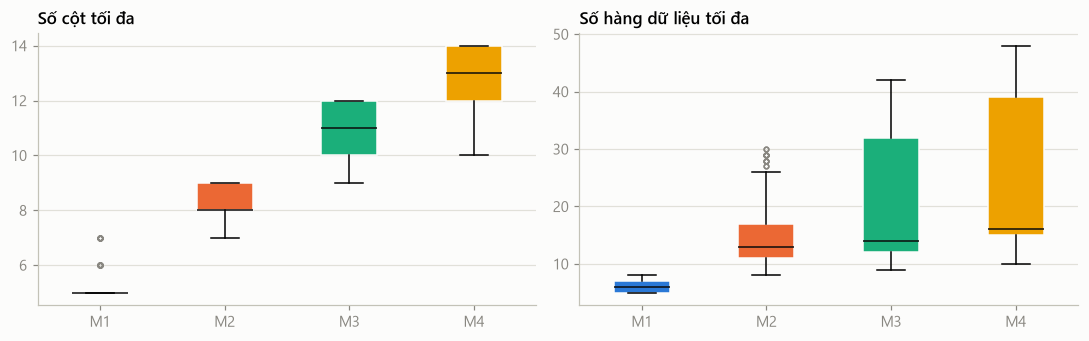

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, column, title in zip(axes, ["max_columns", "max_data_rows"], ["Số cột tối đa", "Số hàng dữ liệu tối đa"]):
    boxes = ax.boxplot([train.loc[train.difficulty == level, column] for level in LEVELS], tick_labels=LEVELS,
                       widths=0.45, patch_artist=True, medianprops={"color": "#0b0b0b"},
                       flierprops={"marker": "o", "markersize": 3, "markeredgecolor": "#898781"})
    for patch, level in zip(boxes["boxes"], LEVELS):
        patch.set(facecolor=LEVEL_COLORS[level], edgecolor="#fcfcfb")
    ax.set_title(title)
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Nhận xét**
- Độ khó tăng đều theo mọi trục: số cột (M1: 5-7 → M4: 10-14), số hàng (M1 ≤ 8 → M4 tới 48), số bảng, tỉ lệ 2 trang.
- **M1-M2 (giống test) đều kẻ viền đầy đủ**, ≤ 9 cột, ≤ 2 bảng, không có `\|`. Kẻ viền thiếu/không viền chỉ có ở M3–M4.
- **Mọi tài liệu M2 đều có ô gộp và ô nhiều dòng**; 11% có bảng vắt qua trang.

## 4. Ảnh trang

In [4]:
sizes = pd.DataFrame([
    {"Nhóm": record.get("difficulty", split), "Kích thước": "{}×{}".format(*Image.open(DATA / split / path).size)}
    for split, frame in frames.items() for record in frame.to_dict("records") for path in record["image_paths"]
])
pd.crosstab(sizes["Nhóm"], sizes["Kích thước"])

Kích thước,1600×2263,1800×2546,2000×2828
Nhóm,,,
M1,325,0,0
M2,0,366,0
M3,0,0,418
M4,0,0,266
private_test,30,56,0
public_test,20,32,0


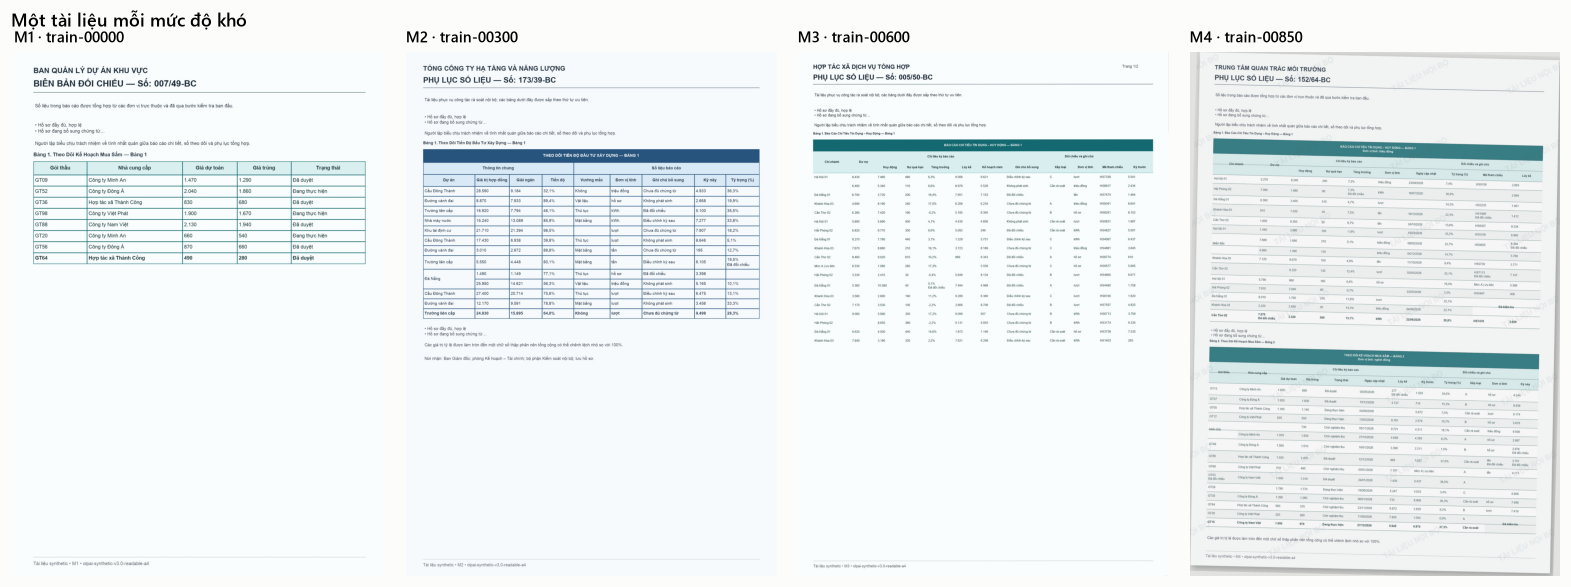

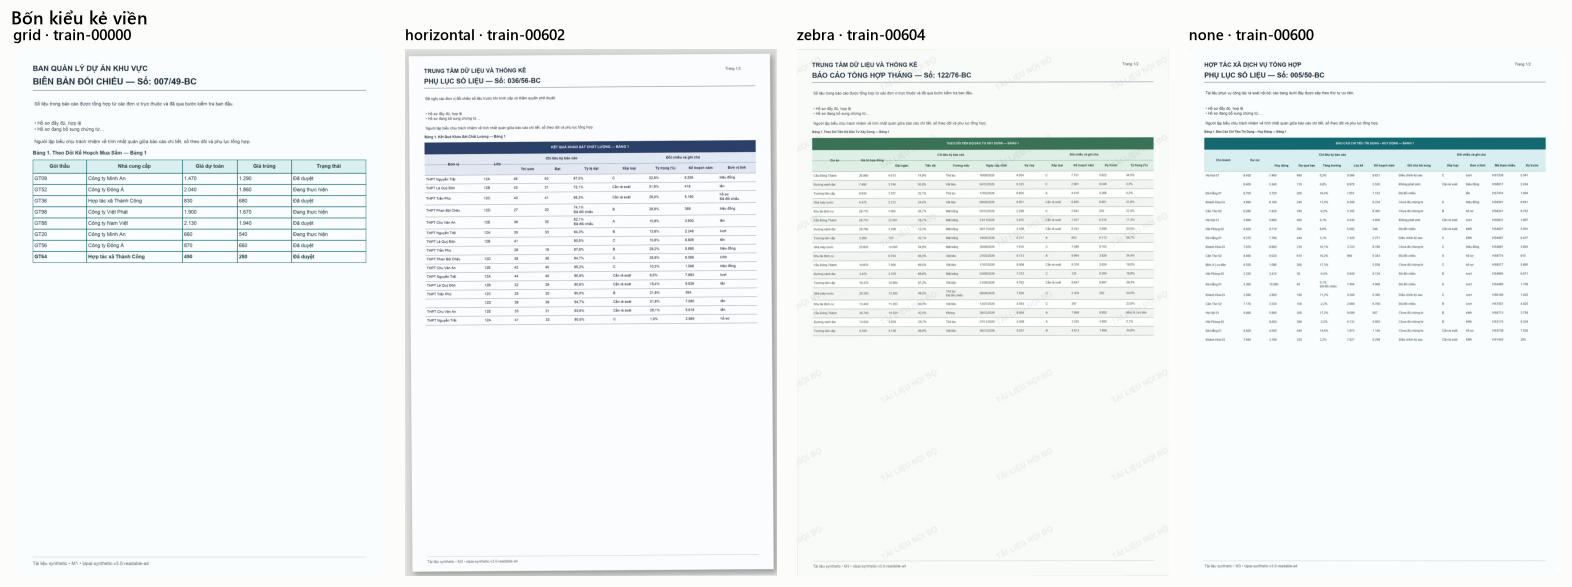

In [5]:
def show_pages(samples: dict, title: str) -> None:
    '''Vẽ trang đầu của mỗi tài liệu mẫu cạnh nhau.'''
    fig, axes = plt.subplots(1, len(samples), figsize=(3.6 * len(samples), 5.4))
    for ax, (caption, record) in zip(axes, samples.items()):
        ax.imshow(Image.open(DATA / "training_set" / record["image_paths"][0]))
        ax.set_title(f"{caption} · {record['id']}", fontsize=10)
        ax.axis("off")
    fig.suptitle(title, x=0.01, ha="left", fontweight="semibold")
    plt.tight_layout()
    plt.show()


show_pages({level: train[train.difficulty == level].iloc[0] for level in LEVELS}, "Một tài liệu mỗi mức độ khó")
show_pages({mode: train[train.border_mode == mode].iloc[0] for mode in ["grid", "horizontal", "zebra", "none"]},
           "Bốn kiểu kẻ viền")

**Nhận xét**
- **Kích thước ảnh trùng 1–1 với mức độ khó**: M1 = 1600×2263, M2 = 1800×2546, M3–M4 = 2000×2828. Test chỉ có hai cỡ đầu → biết được tài liệu test là M1 hay M2 ngay từ kích thước ảnh.
- Mỗi trang còn có tiêu đề, đoạn văn, chú thích "Bảng …" và chân trang → phải tìm đúng vùng bảng giữa các chữ khác.

## 5. Nhãn Markdown

In [6]:
# Một nhãn M2 ngắn có đủ ô gộp ngang/dọc và ô nhiều dòng
labels = {record["id"]: read_label(DATA / "training_set", record) for record in train.to_dict("records")}
example = min((labels[id_] for id_ in train.id[train.difficulty == "M2"]
               if all(token in labels[id_] for token in ("[[H]]", "[[V]]", "<br>"))), key=len)
print(example)

| **KẾT QUẢ KHẢO SÁT CHẤT LƯỢNG — BẢNG 1** | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] |
| --- | --- | --- | --- | --- | --- | --- |
| **Thông tin chung** | [[H]] | [[H]] | **Số liệu báo cáo** | [[H]] | [[H]] | [[H]] |
| **Đơn vị** | **Lớp** | **Thí sinh** | **Đạt** | **Tỷ lệ đạt** | **Tỷ trọng (%)** | **Lũy kế** |
| THPT Nguyễn Trãi | 12A | 46 | 43 | 93,5% | 16,5% | 3.502 |
| THPT Lê Quý Đôn | 12B | 37 | 33 | 89,2% | 14,3% | 7.379 |
| THPT Trần Phú | 12C | 44 | 40 | 90,9% | 5,6% | 1.853 |
|  | 12D |  | 34 | 97,1% | 3,5% | 2.060 |
| THPT Chu Văn An | 12E | 46 | 42 | 91,3% | 35,3% | 5.740 |
| THPT Nguyễn Trãi<br>Đã đối chiếu | 12A | 33 | 33 | 100,0% | 19,6% | 7.555 |
| Miền Bắc | 12B | 43 | 37 | 86,0% | 17,0% | 6.795 |
| [[V]] | 12C | 32 | 21 | 65,6% | 7,4% | 1.400 |
| THPT Phan Bội Châu | 12D | 48 | 47 | 97,9% | 37,2% | 1.646 |
| THPT Chu Văn An | 12E | 39 | 34 | 87,2% | 19,7% | 8.666 |
| THPT Nguyễn Trãi | 12A | 44 | 38 | 86,4% | 17,0% | 802 |
| **THPT Lê Quý Đôn** | **12B** | **4

In [7]:
cells = pd.DataFrame([      # mỗi hàng một ô của nhãn train
    {"difficulty": record["difficulty"], "table": f"{record['id']}#{t}", "row": r, "col": c,
     "last_row": r == len(table) - 1, "text": text}
    for record in train.to_dict("records")
    for t, table in enumerate(parse_markdown(labels[record["id"]]))
    for r, row in enumerate(table) for c, text in enumerate(row)
])
cells["bold"] = cells.text.str.startswith("**") & cells.text.str.endswith("**")
cells["kind"] = np.select(
    [cells.text.eq("[[H]]"), cells.text.eq("[[V]]"), cells.text.eq(""), cells.bold],
    ["Gộp ngang [[H]]", "Gộp dọc [[V]]", "Trống", "Chữ in đậm"], default="Chữ thường")
cells["multiline"] = cells.text.str.contains("<br>", regex=False)
cells["pipe"] = cells.text.str.contains("\\|", regex=False)   # regex=False: tìm đúng chuỗi \|

print(f"{len(cells):,} ô trong {cells.groupby('difficulty').size().to_dict()}")
composition = pd.crosstab(cells.difficulty, cells.kind, normalize="index") * 100
composition = composition[["Chữ thường", "Chữ in đậm", "Gộp ngang [[H]]", "Gộp dọc [[V]]", "Trống"]]
composition[["Có <br>", "Có \\|"]] = cells.groupby("difficulty")[["multiline", "pipe"]].mean() * 100
composition.round(1)

253,439 ô trong {'M1': 12424, 'M2': 58967, 'M3': 101790, 'M4': 80258}


kind,Chữ thường,Chữ in đậm,Gộp ngang [[H]],Gộp dọc [[V]],Trống,Có <br>,Có \|
difficulty,,,,,,,
M1,73.1,26.9,0.0,0.0,0.0,0.0,0.0
M2,73.0,14.6,10.1,0.7,1.6,0.8,0.0
M3,73.8,12.5,9.1,1.9,2.6,1.6,0.5
M4,77.2,10.4,8.0,1.4,3.0,2.3,0.4


In [8]:
# % ô có chữ được in đậm, theo vị trí hàng trong bảng
text_cells = cells[cells.kind.isin(["Chữ thường", "Chữ in đậm"])]
position = np.select([text_cells.last_row, text_cells.row.le(2)],
                     ["Hàng cuối", "Hàng " + text_cells.row.astype(str)], "Hàng giữa")
bold_by_row = pd.crosstab(text_cells.difficulty, position, values=text_cells.bold, aggfunc="mean") * 100
display(bold_by_row[["Hàng 0", "Hàng 1", "Hàng 2", "Hàng giữa", "Hàng cuối"]].round(1))

# Hàng 0 có phải tên bảng gộp ngang hết chiều rộng không?
first_row = cells[cells.row.eq(0) & cells.col.gt(0)]
title_row = first_row.text.eq("[[H]]").groupby([first_row.difficulty, first_row.table]).all()
print("% bảng có hàng 0 gộp ngang toàn bộ:", (title_row.groupby(level=0).mean() * 100).round(0).to_dict())

col_0,Hàng 0,Hàng 1,Hàng 2,Hàng giữa,Hàng cuối
difficulty,,,,,
M1,100.0,0.0,0.0,0.0,100.0
M2,100.0,100.0,100.0,0.0,100.0
M3,100.0,100.0,100.0,0.6,100.0
M4,100.0,100.0,100.0,0.4,100.0


% bảng có hàng 0 gộp ngang toàn bộ: {'M1': 0.0, 'M2': 100.0, 'M3': 100.0, 'M4': 100.0}


In [9]:
plain = (text_cells.text.str.replace("**", "", regex=False)
         .str.replace("<br>", " ", regex=False).str.replace("\\|", "|", regex=False))
lengths = plain.str.len()
numeric = plain.str.fullmatch(r"[-+]?[\d.,]+%?").mean()
print(f"Độ dài ô: trung vị {lengths.median():.0f}, lớn nhất {lengths.max()} ký tự")
print(f"Ô chỉ chứa số (1.470, 2,3%...): {numeric:.0%}")
charset = "".join(sorted(set("".join(plain))))
print(f"{len(charset)} ký tự khác nhau:\n{charset}")

Độ dài ô: trung vị 5, lớn nhất 80 ký tự
Ô chỉ chứa số (1.470, 2,3%...): 54%
159 ký tự khác nhau:
 %()+,-./0123456789:;ABCDEFGHIKLMNOPQRSTUVWXYabcdeghiklmnopqrstuvxy|ÀÁÂÃÊÌÍÔÕàáâãéêìíòóôõúýăĐđũƠơƯưẠạẢảẤấẦầẬậẮắằẵặẹẺẾếềỂểỄễỆệỈỉỊịọỏỐốỒồỔổỘộớỜờởỡỢợỤụủứừửỮỰựỳỷ–—


**Nhận xét**
- **Khung tiêu đề cố định**: M1 có 1 hàng tiêu đề; M2–M4 luôn có 3 hàng, hàng 0 là tên bảng gộp ngang toàn bộ, hàng 1 là nhóm cột (có `[[H]]`), hàng 2 là tên cột.
- **In đậm chỉ phụ thuộc vị trí**: các hàng tiêu đề và hàng cuối đậm 100%, hàng giữa 0% (M1-M2). M3-M4 có thêm vài ô đậm lẻ ở hàng giữa.
- Ô gộp `[[H]]` chiếm ~8-10% số ô ở M2–M4 (phần lớn nằm trong khung tiêu đề), `[[V]]` chỉ 1-2%.
- Ô ngắn (trung vị 11 ký tự), khoảng một nửa là số kiểu Việt Nam (`1.470`, `2,3%`), có đủ chữ có dấu → OCR phải giữ đúng dấu và dấu chấm/phẩy trong số.

## 6. Kết luận cho pipeline

1. **Test = M1-M2**: bảng kẻ viền đầy đủ, ≤ 9 cột, ≤ 2 bảng → phát hiện đường kẻ là đủ; chọn phương pháp theo điểm M1+M2.
2. **Kích thước ảnh cho biết mức độ** (1600 → M1, 1800 → M2) → có thể đặt tham số riêng cho từng mức.
3. **Cấu trúc bảng có khuôn**: M1 một hàng tiêu đề; M2 ba hàng tiêu đề với hàng tên bảng gộp ngang toàn bộ → dùng làm ràng buộc khi dựng lưới ô.
4. **In đậm suy được từ vị trí**: đậm cả các hàng tiêu đề và hàng cuối, không đậm hàng giữa → không cần mô hình nhận dạng in đậm cho M1–M2.
5. **Điểm dễ mất nằm ở M2**: mọi tài liệu có ô gộp và ô nhiều dòng; một số bảng vắt qua trang cần ghép đúng, lệch số bảng là gần như mất trắng tài liệu đó.
6. **OCR**: ô ngắn, nhiều số định dạng Việt Nam và chữ có dấu → ưu tiên mô hình OCR tiếng Việt (VietOCR).